In [37]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Construction des caractéristiques RFM

Ce notebook transforme les transactions nettoyées en une table au niveau client.

Deux versions des caractéristiques RFM sont conservées :

- **RFM achats valides** : calculé uniquement sur les achats positifs, hors annulations ;
- **RFM global** : calculé sur toutes les transactions rattachées à un client, annulations incluses.

Les caractéristiques complémentaires décrivent les clients pour l'interprétation des segments. Les deux blocs RFM sont analysés, transformés et exportés avec ces variables descriptives.

In [38]:
data_path = Path("../data/processed/clean_data.csv")
df = pd.read_csv(data_path)

required_columns = {
    "CustomerID", "Invoice", "InvoiceDate", "Quantity", "Price",
    "StockCode", "Description", "Country"
}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Colonnes manquantes : {sorted(missing_columns)}")

print(f"Transactions chargées : {len(df):,}")
display(df.head())

Transactions chargées : 794,498


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


## 1. Préparation des transactions

Les dates et les montants de ligne sont convertis ou calculés. Deux bases sont ensuite préparées :

- `df_purchases` contient les achats valides, utilisés pour le premier RFM ;
- `df_customer_transactions` contient toutes les transactions client, utilisées pour le RFM global.

Les clients sans identifiant sont écartés, car une transaction ne peut pas être agrégée au niveau client sans `CustomerID`.

In [39]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Invoice"] = df["Invoice"].astype(str)
df["TotalAmount"] = df["Quantity"] * df["Price"]

is_cancellation = df["Invoice"].str.startswith("C")
is_valid_purchase = (
    ~is_cancellation
    & (df["Quantity"] > 0)
    & (df["Price"] > 0)
    & df["CustomerID"].notna()
)
df_purchases = df.loc[is_valid_purchase].copy()
df_customer_transactions = df.loc[df["CustomerID"].notna()].copy()

date_reference = df_customer_transactions["InvoiceDate"].max() + pd.Timedelta(days=1)

print(f"Annulations : {is_cancellation.sum():,}")
print(f"Achats valides rattachés à un client : {len(df_purchases):,}")
print(f"Transactions client conservées pour le RFM global : {len(df_customer_transactions):,}")
print(f"Date de référence : {date_reference.date()}")

Annulations : 17,596
Achats valides rattachés à un client : 776,902
Transactions client conservées pour le RFM global : 794,498
Date de référence : 2011-12-10


## 2. Construction des caractéristiques client

Pour chaque client, les deux RFM contiennent :

- **Récence** : nombre de jours depuis la dernière transaction de la base considérée ;
- **Fréquence** : nombre de factures distinctes ;
- **Montant** : somme des montants de ligne.

Le RFM global mesure donc un montant net après annulations. Les variables complémentaires sont calculées sur les achats valides : pays de résidence le plus fréquent, nombre de produits distincts et produit le plus acheté. Le nombre d'annulations est calculé séparément sur toutes les transactions.

In [43]:
rfm_columns = ["recence_jours", "frequence", "montant_total"]
global_rfm_columns = [
    "recence_globale_jours", "frequence_globale", "montant_global"
]

rfm = df_purchases.groupby("CustomerID").agg(
    recence_jours=("InvoiceDate", lambda dates: (date_reference - dates.max()).days),
    frequence=("Invoice", "nunique"),
    montant_total=("TotalAmount", "sum"),
)

rfm_global = df_customer_transactions.groupby("CustomerID").agg(
    recence_globale_jours=("InvoiceDate", lambda dates: (date_reference - dates.max()).days),
    frequence_globale=("Invoice", "nunique"),
    montant_global=("TotalAmount", "sum"),
).reindex(rfm.index)

profil_client = df_purchases.groupby("CustomerID").agg(
    pays_residence=("Country", lambda values: values.mode().iat[0]),
    nb_produits_distincts=("StockCode", "nunique"),
)

annulations = (
    df.loc[is_cancellation & df["CustomerID"].notna()]
    .groupby("CustomerID")
    .size()
    .rename("nb_annulations")
)

# En cas d'égalité, le tri rend le choix du produit reproductible.
produit_top = (
    df_purchases.groupby(["CustomerID", "StockCode", "Description"], dropna=False)["Quantity"]
    .sum()
    .rename("quantite_achetee")
    .reset_index()
    .sort_values(["CustomerID", "quantite_achetee", "StockCode"], ascending=[True, False, True])
    .drop_duplicates("CustomerID")
    .set_index("CustomerID")
    .rename(columns={
        "StockCode": "produit_top_code",
        "Description": "produit_top_description",
    })[["produit_top_code", "produit_top_description"]]
)

features_clients = (
    rfm.join(rfm_global)
    .join(profil_client)
    .join(annulations)
    .join(produit_top)
    .fillna({"nb_annulations": 0})
    .reset_index()
    .astype({"nb_annulations": "int64"})
)

assert features_clients[rfm_columns + global_rfm_columns].notna().all().all()
assert (features_clients[["recence_jours", "recence_globale_jours"]] >= 0).all().all()
assert (features_clients[["frequence", "montant_total", "frequence_globale"]] > 0).all().all()
assert len(rfm) == len(rfm_global) == len(features_clients)

print(f"Clients après agrégation : {len(features_clients):,}")
display(features_clients.head())

Clients après agrégation : 5,856


,CustomerID,recence_jours,frequence,montant_total,recence_globale_jours,frequence_globale,montant_global,pays_residence,nb_produits_distincts,nb_annulations,produit_top_code,produit_top_description
0,12346,326,12,"77,556.46",326,14,368.36,United Kingdom,25,2,23166,MEDIUM CERAMIC TOP STORAGE JAR
1,12347,2,8,"4,921.53",2,8,"4,921.53",Iceland,119,0,23076,ICE CREAM SUNDAE LIP GLOSS
2,12348,75,5,"1,658.40",75,5,"1,658.40",Finland,24,0,23077,DOUGHNUT LIP GLOSS
3,12349,19,3,"3,678.69",19,4,"3,654.54",Italy,136,5,21231,SWEETHEART CERAMIC TRINKET BOX
4,12350,310,1,294.40,310,1,294.40,Norway,16,0,22348,TEA BAG PLATE RED RETROSPOT


## 3. Analyse statistique des deux RFM

L'analyse porte sur les variables qui pourront servir à la modélisation. Pour chaque bloc, on examine :

- les statistiques descriptives et les quantiles pour comparer les échelles ;
- les histogrammes pour visualiser les distributions ;
- l'asymétrie (`skewness`) pour repérer les valeurs extrêmes ;
- les corrélations de Spearman pour étudier les relations monotones entre récence, fréquence et montant.

La comparaison permet de mesurer l'effet des annulations sur la fréquence et le montant global.


Achats valides - statistiques descriptives


,count,mean,std,min,50%,75%,90%,99%,max
recence_jours,"5,856.00",200.38,208.67,1.00,95.00,379.00,532.00,726.00,739.00
frequence,"5,856.00",6.25,12.76,1.00,3.00,7.00,13.00,46.00,375.00
montant_total,"5,856.00","2,919.21","14,344.75",2.95,856.02,"2,241.03","5,395.45","28,611.37","580,987.04"


Achats valides - asymétrie


,skewness
recence_jours,0.89
frequence,12.08
montant_total,25.30


Achats valides - corrélations de Spearman


...

,count,mean,std,min,50%,75%,90%,99%,max
recence_globale_jours,"5,856.00",197.90,207.91,1.00,92.00,376.00,528.50,725.00,739.00
frequence_globale,"5,856.00",7.49,15.41,1.00,4.00,8.00,16.00,55.45,468.00
montant_global,"5,856.00","2,798.16","13,862.82","-1,343.24",840.25,"2,172.03","5,244.23","26,479.61","578,408.64"


RFM global - asymétrie


,skewness
recence_globale_jours,0.90
frequence_globale,11.99
montant_global,26.78


RFM global - corrélations de Spearman


,recence_globale_jours,frequence_globale,montant_global
recence_globale_jours,1.00,-0.54,-0.51
frequence_globale,-0.54,1.00,0.85
montant_global,-0.51,0.85,1.00


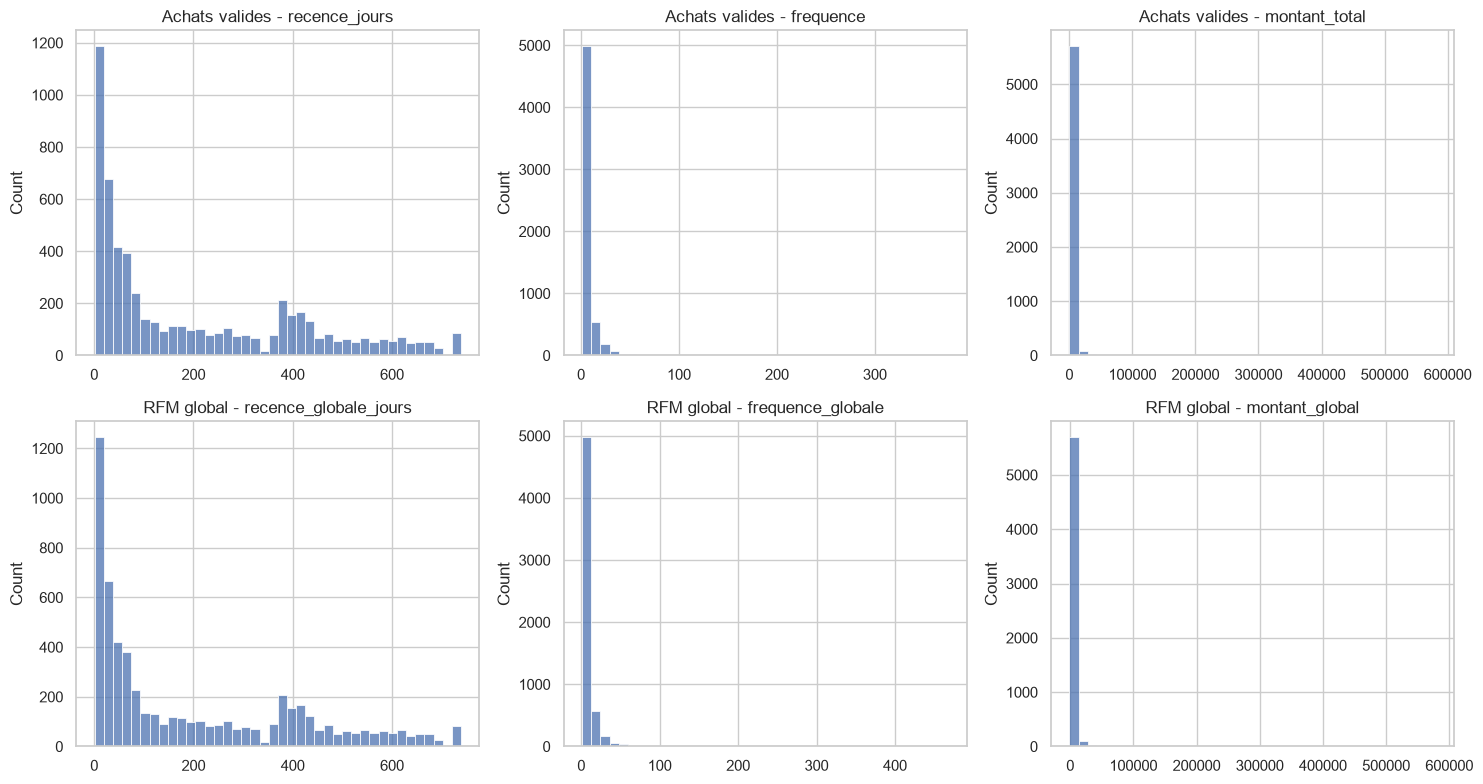

In [44]:
rfm_groups = {
    "Achats valides": rfm_columns,
    "RFM global": global_rfm_columns,
}

for group_name, columns in rfm_groups.items():
    print(f"\n{group_name} - statistiques descriptives")
    display(features_clients[columns].describe(percentiles=[0.50, 0.75, 0.90, 0.99]).T)
    print(f"{group_name} - asymétrie")
    display(features_clients[columns].skew().to_frame("skewness"))
    print(f"{group_name} - corrélations de Spearman")
    display(features_clients[columns].corr(method="spearman"))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, (group_name, columns) in enumerate(rfm_groups.items()):
    for axis, column in zip(axes[row], columns):
        sns.histplot(features_clients[column], bins=40, ax=axis)
        axis.set_title(f"{group_name} - {column}")
        axis.set_xlabel("")
plt.tight_layout()
plt.show()

## 4. Transformations et export

Les distributions RFM sont asymétriques, surtout pour la fréquence et le montant. La transformation `log1p(x)` réduit l'influence des valeurs extrêmes tout en restant définie en zéro. Elle est appliquée aux variables RFM positives.

Le montant global est un montant net : il peut être négatif lorsque les annulations dépassent les achats. Il utilise donc une transformation logarithmique signée, `sign(x) * log1p(abs(x))`, qui réduit l'effet des valeurs extrêmes tout en conservant le signe.

`StandardScaler` centre ensuite chaque variable transformée et la ramène à une échelle comparable. Les colonnes suffixées `_scaled` sont prêtes pour la modélisation :

- `recence_jours_scaled`, `frequence_scaled`, `montant_total_scaled` pour les achats valides ;
- `recence_globale_jours_scaled`, `frequence_globale_scaled`, `montant_global_scaled` pour le RFM global.

Le fichier exporté contient les RFM bruts, les versions transformées et les variables complémentaires.


Achats valides - asymétrie après transformation


,skewness
recence_jours_log,-0.49
frequence_log,1.00
montant_total_log,0.27


Achats valides - moyennes après standardisation


,moyenne
recence_jours_scaled,-0.00
frequence_scaled,0.00
montant_total_scaled,0.00


Achats valides - écarts-types après standardisation


...

,skewness
recence_globale_jours_log,-0.48
frequence_globale_log,0.89
montant_global_log,-0.35


RFM global - moyennes après standardisation


,moyenne
recence_globale_jours_scaled,0.00
frequence_globale_scaled,0.00
montant_global_scaled,-0.00


RFM global - écarts-types après standardisation


,ecart_type
recence_globale_jours_scaled,1.00
frequence_globale_scaled,1.00
montant_global_scaled,1.00


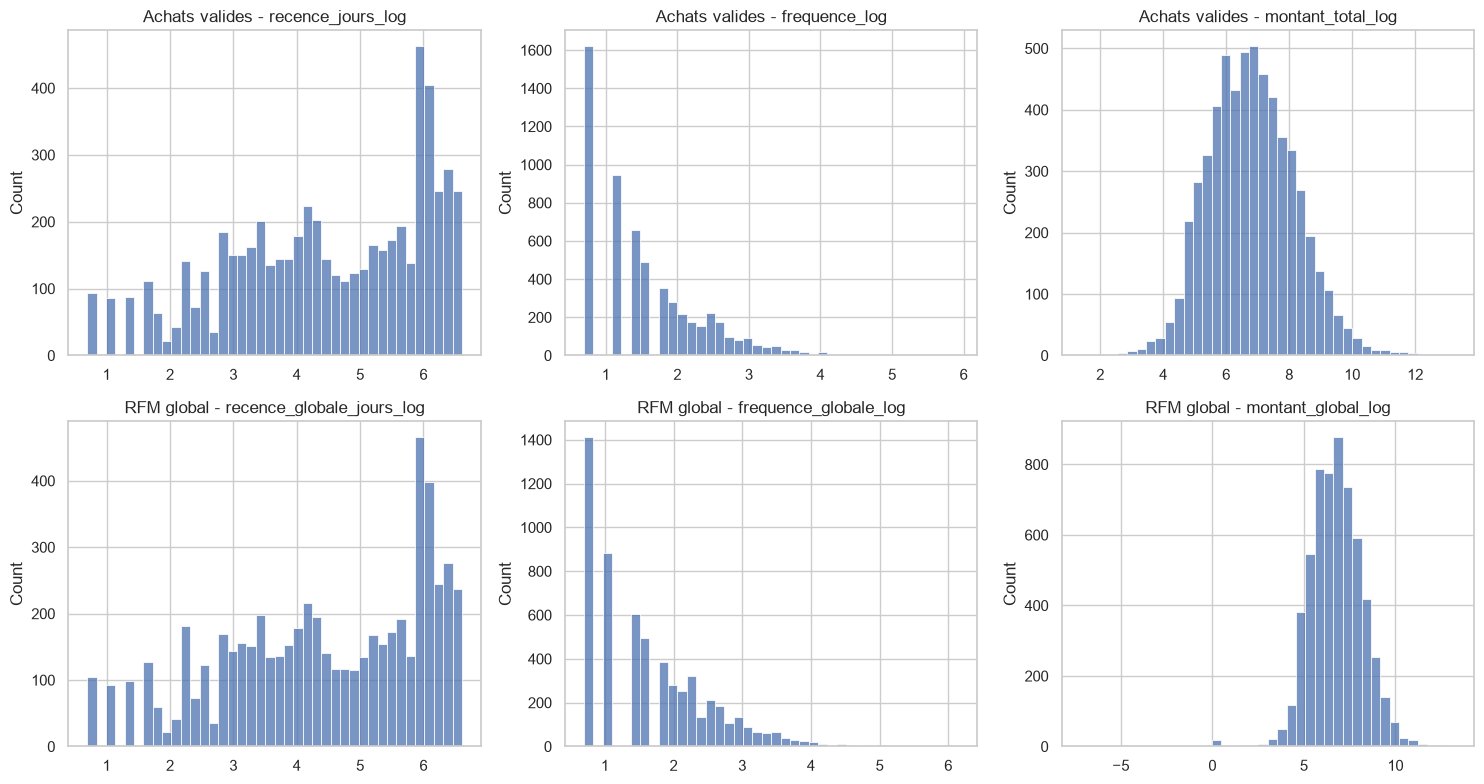

Fichier sauvegardé : ..\data\processed\features_rfm_datacsv
Dimensions exportées : 5,856 clients x 24 colonnes


In [45]:
log_groups = {
    "Achats valides": rfm_columns,
    "RFM global": global_rfm_columns,
}

scaled_groups = {}
for group_name, columns in log_groups.items():
    log_columns_group = [f"{column}_log" for column in columns]
    scaled_columns_group = [f"{column}_scaled" for column in columns]
    values = features_clients[columns]

    if "montant_global" in columns:
        transformed_values = values.copy()
        for column in columns:
            if column == "montant_global":
                transformed_values[column] = np.sign(values[column]) * np.log1p(values[column].abs())
            else:
                transformed_values[column] = np.log1p(values[column])
    else:
        transformed_values = np.log1p(values)

    features_clients[log_columns_group] = transformed_values.to_numpy()
    scaler_group = StandardScaler()
    features_clients[scaled_columns_group] = scaler_group.fit_transform(
        features_clients[log_columns_group]
    )
    scaled_groups[group_name] = scaled_columns_group

    print(f"\n{group_name} - asymétrie après transformation")
    display(features_clients[log_columns_group].skew().to_frame("skewness"))
    print(f"{group_name} - moyennes après standardisation")
    display(features_clients[scaled_columns_group].mean().round(6).to_frame("moyenne"))
    print(f"{group_name} - écarts-types après standardisation")
    display(features_clients[scaled_columns_group].std(ddof=0).round(6).to_frame("ecart_type"))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, (group_name, columns) in enumerate(log_groups.items()):
    for axis, column in zip(axes[row], [f"{name}_log" for name in columns]):
        sns.histplot(features_clients[column], bins=40, ax=axis)
        axis.set_title(f"{group_name} - {column}")
        axis.set_xlabel("")
plt.tight_layout()
plt.show()

output_path = Path("../data/processed/features_rfm_datacsv")
features_clients.to_csv(output_path, index=False)
print(f"Fichier sauvegardé : {output_path}")
print(f"Dimensions exportées : {features_clients.shape[0]:,} clients x {features_clients.shape[1]} colonnes")